In [1]:
# ── Wavelet Analysis Notebook ─────────────────────────────────
# Cell 1 — Imports + Config + Load data

import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pywt
import os
import warnings
warnings.filterwarnings('ignore')

# ── Publishable style ─────────────────────────────────────────
FIG_DIR = r'D:\Data science Project\EEG Chrononet\EEGdata\figures'
os.makedirs(FIG_DIR, exist_ok=True)

mpl.rcParams.update({
    'font.size'        : 14,
    'font.weight'      : 'bold',
    'axes.titlesize'   : 16,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 14,
    'axes.labelweight' : 'bold',
    'xtick.labelsize'  : 12,
    'ytick.labelsize'  : 12,
    'legend.fontsize'  : 12,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

def save_fig(fname):
    path = os.path.join(FIG_DIR, fname)
    plt.savefig(path, dpi=600, bbox_inches='tight')
    print(f"Saved: {path}")

# ── Config ────────────────────────────────────────────────────
BASE     = r'D:\Data science Project\EEG Chrononet\EEGdata\Data\CleanData'
CHANNELS = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
SFREQ    = 128
BANDS    = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8,  13),
    'beta' : (13, 30),
    'gamma': (30, 45),
}

MANIFEST = [
    ('NDS001','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS001_Music_CD.mat')),
    ('NDS001','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS001_Rest_CD.mat')),
    ('NDS002','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS002_Music_CD.mat')),
    ('NDS002','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS002_Rest_CD.mat')),
    ('NDS003','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS003_Music_CD.mat')),
    ('NDS003','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS003_Rest_CD.mat')),
    ('NDS004','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS004_Music_CD.mat')),
    ('NDS004','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS004_Rest_CD.mat')),
    ('NDS005','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS005_Music_CD.mat')),
    ('NDS005','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS005_Rest_CD.mat')),
    ('NDS006','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS006_Music_CD.mat')),
    ('NDS006','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS006_Rest_CD.mat')),
    ('NDS007','IDD','Music', os.path.join(BASE,'CleanData_IDD','Music','NDS007_Music_CD.mat')),
    ('NDS007','IDD','Rest',  os.path.join(BASE,'CleanData_IDD','Rest', 'NDS007_Rest_CD.mat')),
    ('CGS01','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS01_Music_CD.mat')),
    ('CGS01','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS01_Rest_CD.mat')),
    ('CGS02','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS02_Music_CD.mat')),
    ('CGS02','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS02_Rest_CD.mat')),
    ('CGS03','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS03_Music_CD.mat')),
    ('CGS03','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS03_Rest_CD.mat')),
    ('CGS04','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS04_Music_CD.mat')),
    ('CGS04','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS04_Rest_CD.mat')),
    ('CGS05','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS05_Music_CD.mat')),
    ('CGS05','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS05_Rest_CD.mat')),
    ('CGS06','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS06_Music_CD.mat')),
    ('CGS06','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS06_Rest_CD.mat')),
    ('CGS07','TDC','Music', os.path.join(BASE,'CleanData_TDC','Music','CGS07_Music_CD.mat')),
    ('CGS07','TDC','Rest',  os.path.join(BASE,'CleanData_TDC','Rest', 'CGS07_Rest_CD.mat')),
]

# ── Load ──────────────────────────────────────────────────────
data = {}
for subj, group, cond, fpath in MANIFEST:
    mat = sio.loadmat(fpath)
    data[(subj, cond)] = {
        'eeg'  : mat['clean_data'].astype(np.float32),
        'group': group, 'subj': subj, 'cond': cond
    }

print(f"Loaded {len(data)} recordings ✅")
print(f"PyWavelets version: {pywt.__version__}")
print(f"Available wavelets (sample): {pywt.wavelist(kind='continuous')[:8]}")

Loaded 28 recordings ✅
PyWavelets version: 1.8.0
Available wavelets (sample): ['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8']


Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_cwt_scalogram.png


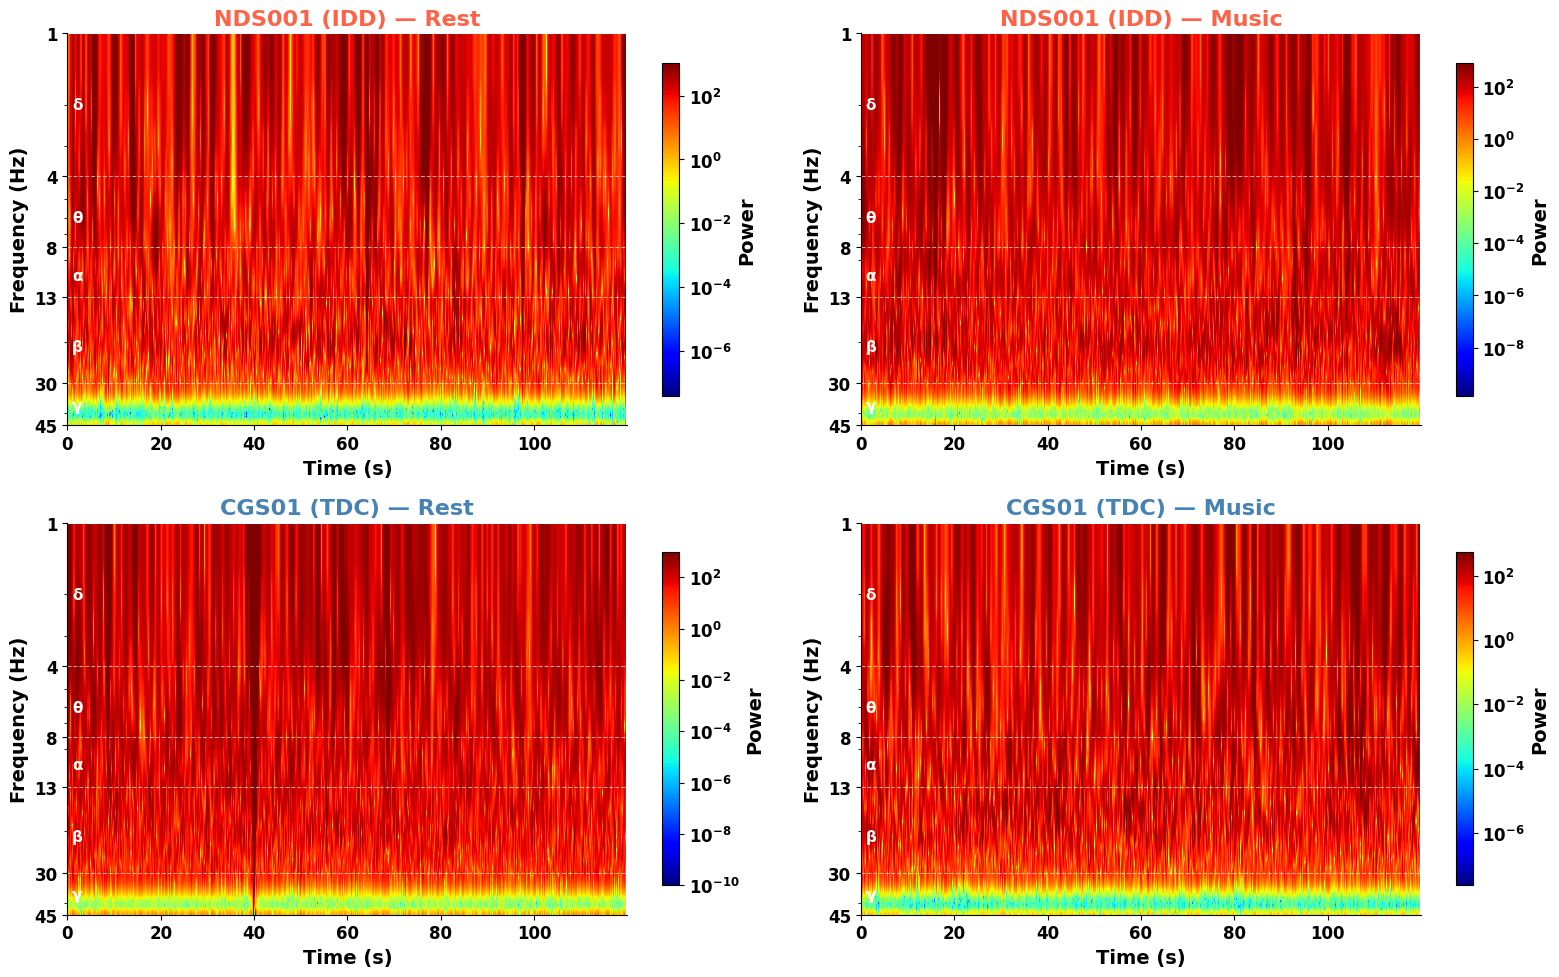

In [3]:
# Cell 2 — CWT Scalogram: IDD vs TDC, Rest vs Music (channel AF3)

from matplotlib.colors import LogNorm

# Frequencies to analyze (1–45 Hz, log-spaced)
freqs    = np.logspace(np.log10(1), np.log10(45), 60)
scales   = SFREQ / (freqs * 2)   # morlet scale conversion (pywt uses scale not freq)
wavelet  = 'cmor1.5-1.0'         # complex morlet: bandwidth=1.5, center freq=1.0
ch_idx   = CHANNELS.index('AF3')

# Band boundary lines for annotation
band_freqs = [1, 4, 8, 13, 30, 45]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pairs = [('NDS001','IDD','Rest'), ('NDS001','IDD','Music'),
         ('CGS01', 'TDC','Rest'), ('CGS01', 'TDC','Music')]

for ax, (subj, group, cond) in zip(axes.flat, pairs):
    eeg = data[(subj, cond)]['eeg'][ch_idx].astype(np.float64)
    t   = np.arange(len(eeg)) / SFREQ

    # Clip spike before CWT
    eeg = np.clip(eeg, -5*eeg.std(), 5*eeg.std())

    # CWT
    coef, _ = pywt.cwt(eeg, scales, wavelet, sampling_period=1/SFREQ)
    power   = np.abs(coef) ** 2   # (n_freqs, n_times)

    # Plot
    im = ax.imshow(power,
                   extent   = [0, t[-1], freqs[-1], freqs[0]],
                   aspect   = 'auto',
                   cmap     = 'jet',
                   norm     = LogNorm(vmin=power.min()+1e-10,
                                      vmax=np.percentile(power, 99)),
                   origin   = 'upper')

    # Band boundary lines
    for bf in band_freqs:
        ax.axhline(bf, color='white', linewidth=0.8, linestyle='--', alpha=0.6)

    # Band labels
    band_mids = [2, 6, 10.5, 21, 37]
    bnames    = ['δ','θ','α','β','γ']
    for bm, bn in zip(band_mids, bnames):
        ax.text(1, bm, bn, color='white', fontsize=11,
                fontweight='bold', va='center')

    color = 'tomato' if group == 'IDD' else 'steelblue'
    ax.set_title(f'{subj} ({group}) — {cond}', color=color)
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel('Time (s)')
    ax.set_yscale('log')
    ax.set_yticks([1, 4, 8, 13, 30, 45])
    ax.set_yticklabels(['1','4','8','13','30','45'])

    plt.colorbar(im, ax=ax, label='Power', shrink=0.85)

plt.tight_layout()
save_fig('fig_cwt_scalogram.png')
plt.show()

Computing CWT band power for all subjects...
  NDS001 Music done
  NDS001 Rest done
  NDS002 Music done
  NDS002 Rest done
  NDS003 Music done
  NDS003 Rest done
  NDS004 Music done
  NDS004 Rest done
  NDS005 Music done
  NDS005 Rest done
  NDS006 Music done
  NDS006 Rest done
  NDS007 Music done
  NDS007 Rest done
  CGS01 Music done
  CGS01 Rest done
  CGS02 Music done
  CGS02 Rest done
  CGS03 Music done
  CGS03 Rest done
  CGS04 Music done
  CGS04 Rest done
  CGS05 Music done
  CGS05 Rest done
  CGS06 Music done
  CGS06 Rest done
  CGS07 Music done
  CGS07 Rest done

Plotting...
Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_cwt_bandpower_group.png


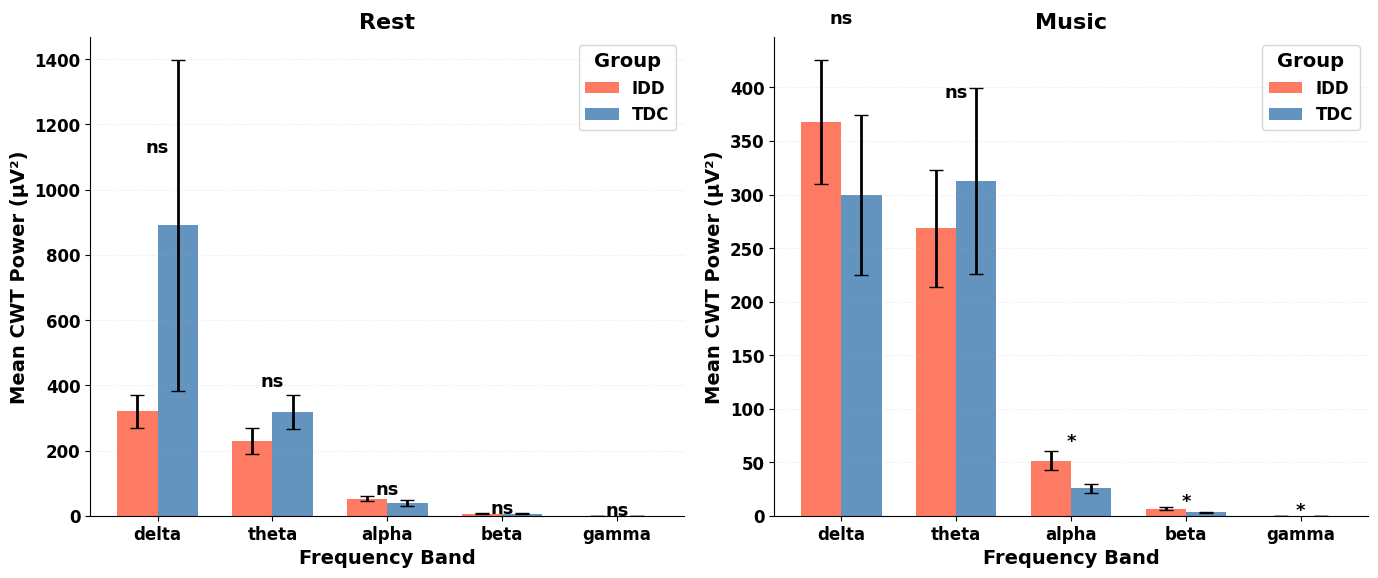

In [5]:
# Cell 3 — Group-averaged band power from CWT across all subjects

from scipy.stats import mannwhitneyu

freqs_cwt = np.logspace(np.log10(1), np.log10(45), 60)
scales    = SFREQ / (freqs_cwt * 2)
wavelet   = 'cmor1.5-1.0'
ch_idx    = CHANNELS.index('AF3')

# Collect mean band power per subject per condition
# result[group][cond][band] = list of scalar values (one per subject)
from collections import defaultdict
bp = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

print("Computing CWT band power for all subjects...")
for subj, group, cond, _ in MANIFEST:
    eeg = data[(subj, cond)]['eeg'][ch_idx].astype(np.float64)
    eeg = np.clip(eeg, -5*eeg.std(), 5*eeg.std())

    coef, _ = pywt.cwt(eeg, scales, wavelet, sampling_period=1/SFREQ)
    power   = np.abs(coef) ** 2   # (n_freqs, n_times)

    for bname, (flo, fhi) in BANDS.items():
        mask = (freqs_cwt >= flo) & (freqs_cwt < fhi)
        bp[group][cond][bname].append(power[mask].mean())

    print(f"  {subj} {cond} done")

print("\nPlotting...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

x      = np.arange(len(BANDS))
width  = 0.35
bnames = list(BANDS.keys())

for ax, cond in zip(axes, ['Rest', 'Music']):
    for offset, (group, color) in enumerate(
            [('IDD','tomato'), ('TDC','steelblue')]):

        means = [np.mean(bp[group][cond][b]) for b in bnames]
        sems  = [np.std(bp[group][cond][b]) /
                 np.sqrt(len(bp[group][cond][b])) for b in bnames]

        bars = ax.bar(x + offset*width, means, width,
                      label=group, color=color, alpha=0.85,
                      yerr=sems, capsize=5, error_kw={'linewidth':2})

    # Significance stars
    for bi, bname in enumerate(bnames):
        idd_vals = bp['IDD'][cond][bname]
        tdc_vals = bp['TDC'][cond][bname]
        stat, p  = mannwhitneyu(idd_vals, tdc_vals, alternative='two-sided')
        y_max    = max(np.mean(idd_vals), np.mean(tdc_vals)) * 1.25
        if p < 0.001:  star = '***'
        elif p < 0.01: star = '**'
        elif p < 0.05: star = '*'
        else:          star = 'ns'
        ax.text(bi + width/2, y_max, star,
                ha='center', fontsize=13, fontweight='bold', color='black')

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(bnames)
    ax.set_title(f'{cond}')
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('Mean CWT Power (µV²)')
    ax.legend(title='Group')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
save_fig('fig_cwt_bandpower_group.png')
plt.show()

Computing per-channel band power for all subjects...
Plotting difference maps...
Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_cwt_diff_map.png


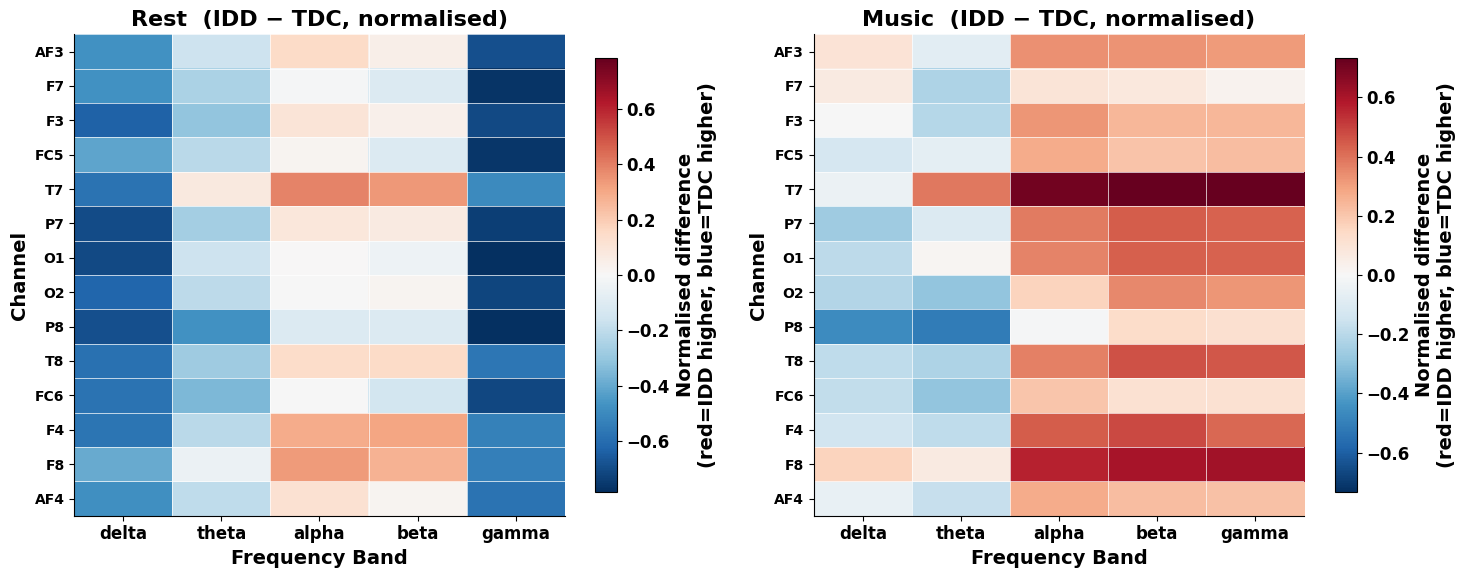

In [7]:
# Cell 4 — Group difference heatmap: IDD minus TDC
# Mean CWT band power per channel per group, then subtract

print("Computing per-channel band power for all subjects...")

# bp_ch[group][cond][band][ch] = list of values (one per subject)
bp_ch = defaultdict(lambda: defaultdict(lambda: defaultdict(
        lambda: defaultdict(list))))

for subj, group, cond, _ in MANIFEST:
    for ch_idx, ch_name in enumerate(CHANNELS):
        eeg = data[(subj, cond)]['eeg'][ch_idx].astype(np.float64)
        eeg = np.clip(eeg, -5*eeg.std(), 5*eeg.std())
        coef, _ = pywt.cwt(eeg, scales, wavelet, sampling_period=1/SFREQ)
        power   = np.abs(coef) ** 2
        for bname, (flo, fhi) in BANDS.items():
            mask = (freqs_cwt >= flo) & (freqs_cwt < fhi)
            bp_ch[group][cond][bname][ch_name].append(power[mask].mean())

print("Plotting difference maps...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bnames = list(BANDS.keys())

for ax, cond in zip(axes, ['Rest', 'Music']):
    diff_matrix = np.zeros((len(CHANNELS), len(bnames)))  # (14, 5)

    for ci, ch_name in enumerate(CHANNELS):
        for bi, bname in enumerate(bnames):
            idd_mean = np.mean(bp_ch['IDD'][cond][bname][ch_name])
            tdc_mean = np.mean(bp_ch['TDC'][cond][bname][ch_name])
            # Normalised difference
            diff_matrix[ci, bi] = (idd_mean - tdc_mean) / (idd_mean + tdc_mean + 1e-10)

    vmax = np.abs(diff_matrix).max()
    im   = ax.imshow(diff_matrix, aspect='auto', cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax)

    ax.set_xticks(range(len(bnames)))
    ax.set_xticklabels(bnames)
    ax.set_yticks(range(len(CHANNELS)))
    ax.set_yticklabels(CHANNELS, fontsize=10)
    ax.set_title(f'{cond}  (IDD − TDC, normalised)')
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('Channel')

    plt.colorbar(im, ax=ax,
                 label='Normalised difference\n(red=IDD higher, blue=TDC higher)',
                 shrink=0.9)

    # Grid lines between cells
    for x in np.arange(-0.5, len(bnames), 1):
        ax.axvline(x, color='white', linewidth=0.5)
    for y in np.arange(-0.5, len(CHANNELS), 1):
        ax.axhline(y, color='white', linewidth=0.5)

plt.tight_layout()
save_fig('fig_cwt_diff_map.png')
plt.show()

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_wavelet_coherence.png


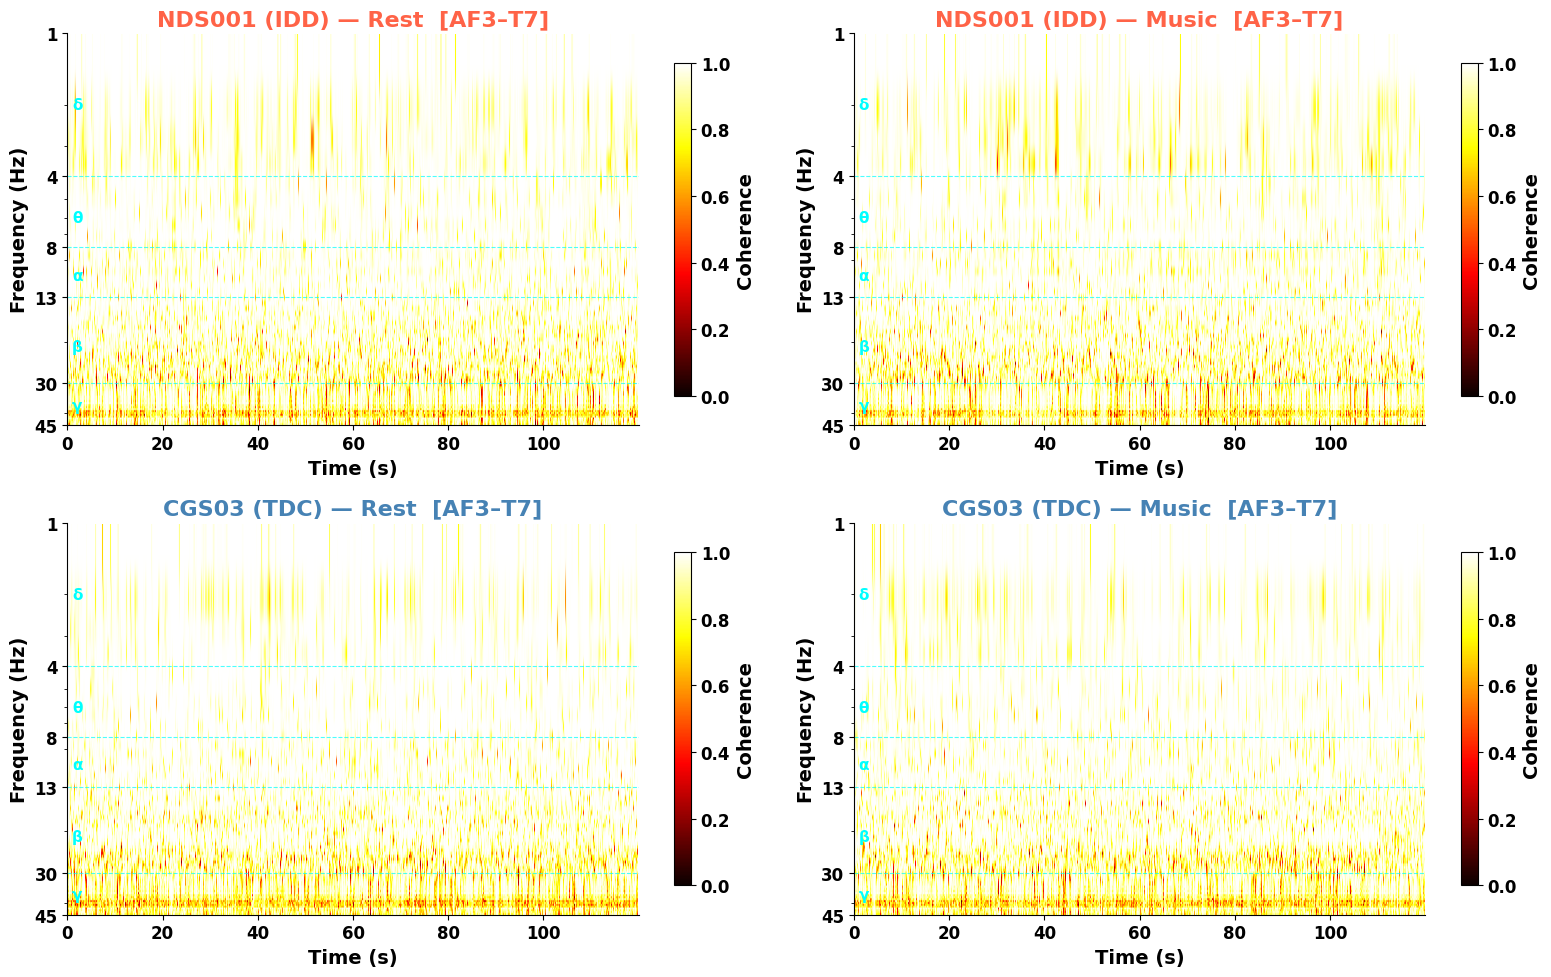

In [9]:
# Cell 5 — Wavelet Coherence: AF3 (frontal) vs T7 (temporal)
# T7 showed strongest IDD>TDC difference in Music — key pair to examine

import matplotlib.gridspec as gridspec

ch1_name, ch2_name = 'AF3', 'T7'
ch1_idx = CHANNELS.index(ch1_name)
ch2_idx = CHANNELS.index(ch2_name)

# Compute wavelet coherence manually via CWT cross-spectrum
def wavelet_coherence(sig1, sig2, scales, wavelet, sfreq):
    coef1, freqs = pywt.cwt(sig1, scales, wavelet, sampling_period=1/sfreq)
    coef2, _     = pywt.cwt(sig2, scales, wavelet, sampling_period=1/sfreq)
    # Cross-spectrum
    cross  = coef1 * np.conj(coef2)
    # Smooth in time (Gaussian kernel)
    from scipy.ndimage import uniform_filter1d
    smooth_cross  = uniform_filter1d(np.abs(cross),  size=10, axis=1)
    smooth_pow1   = uniform_filter1d(np.abs(coef1)**2, size=10, axis=1)
    smooth_pow2   = uniform_filter1d(np.abs(coef2)**2, size=10, axis=1)
    # Coherence
    coherence = (smooth_cross**2) / (smooth_pow1 * smooth_pow2 + 1e-10)
    return coherence, freqs

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pairs = [('NDS001','IDD','Rest'), ('NDS001','IDD','Music'),
         ('CGS03', 'TDC','Rest'), ('CGS03', 'TDC','Music')]

for ax, (subj, group, cond) in zip(axes.flat, pairs):
    sig1 = data[(subj,cond)]['eeg'][ch1_idx].astype(np.float64)
    sig2 = data[(subj,cond)]['eeg'][ch2_idx].astype(np.float64)
    sig1 = np.clip(sig1, -5*sig1.std(), 5*sig1.std())
    sig2 = np.clip(sig2, -5*sig2.std(), 5*sig2.std())

    t = np.arange(len(sig1)) / SFREQ

    coh, freqs_out = wavelet_coherence(sig1, sig2, scales, wavelet, SFREQ)

    im = ax.imshow(coh,
                   extent  = [0, t[-1], freqs_cwt[-1], freqs_cwt[0]],
                   aspect  = 'auto',
                   cmap    = 'hot',
                   vmin    = 0, vmax = 1,
                   origin  = 'upper')

    # Band lines
    for bf in [4, 8, 13, 30]:
        ax.axhline(bf, color='cyan', linewidth=0.8, linestyle='--', alpha=0.7)

    band_mids = [2, 6, 10.5, 21, 37]
    for bm, bn in zip(band_mids, ['δ','θ','α','β','γ']):
        ax.text(1, bm, bn, color='cyan', fontsize=11, fontweight='bold', va='center')

    color = 'tomato' if group == 'IDD' else 'steelblue'
    ax.set_title(f'{subj} ({group}) — {cond}  [{ch1_name}–{ch2_name}]', color=color)
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel('Time (s)')
    ax.set_yscale('log')
    ax.set_yticks([1, 4, 8, 13, 30, 45])
    ax.set_yticklabels(['1','4','8','13','30','45'])

    plt.colorbar(im, ax=ax, label='Coherence', shrink=0.85)

plt.tight_layout()
save_fig('fig_wavelet_coherence.png')
plt.show()

Computing wavelet coherence for all subjects (AF3-T7)...
  NDS001 Music done
  NDS001 Rest done
  NDS002 Music done
  NDS002 Rest done
  NDS003 Music done
  NDS003 Rest done
  NDS004 Music done
  NDS004 Rest done
  NDS005 Music done
  NDS005 Rest done
  NDS006 Music done
  NDS006 Rest done
  NDS007 Music done
  NDS007 Rest done
  CGS01 Music done
  CGS01 Rest done
  CGS02 Music done
  CGS02 Rest done
  CGS03 Music done
  CGS03 Rest done
  CGS04 Music done
  CGS04 Rest done
  CGS05 Music done
  CGS05 Rest done
  CGS06 Music done
  CGS06 Rest done
  CGS07 Music done
  CGS07 Rest done

Plotting...
Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_wavelet_coherence_group.png


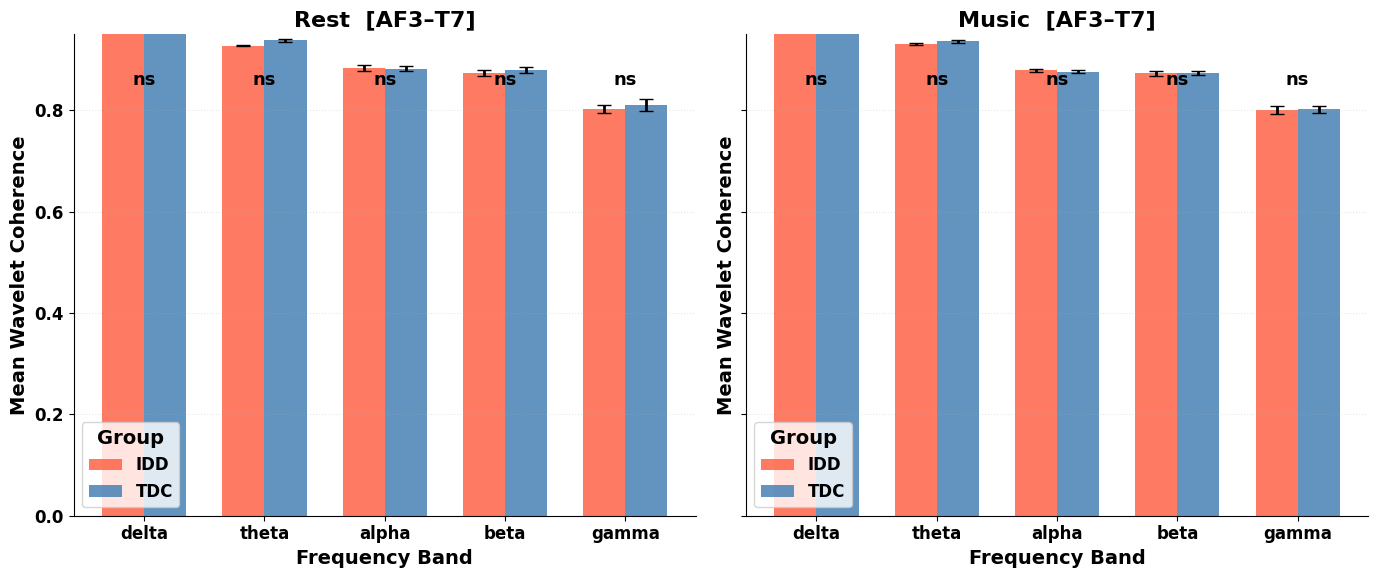

In [11]:
# Cell 6 — Group-averaged wavelet coherence: IDD vs TDC
# AF3-T7 pair, all subjects, both conditions

print("Computing wavelet coherence for all subjects (AF3-T7)...")

coh_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# coh_results[group][cond][band] = list of mean coherence values

for subj, group, cond, _ in MANIFEST:
    sig1 = data[(subj,cond)]['eeg'][ch1_idx].astype(np.float64)
    sig2 = data[(subj,cond)]['eeg'][ch2_idx].astype(np.float64)
    sig1 = np.clip(sig1, -5*sig1.std(), 5*sig1.std())
    sig2 = np.clip(sig2, -5*sig2.std(), 5*sig2.std())

    coh, _ = wavelet_coherence(sig1, sig2, scales, wavelet, SFREQ)

    for bname, (flo, fhi) in BANDS.items():
        mask = (freqs_cwt >= flo) & (freqs_cwt < fhi)
        coh_results[group][cond][bname].append(coh[mask].mean())

    print(f"  {subj} {cond} done")

print("\nPlotting...")

from scipy.stats import mannwhitneyu

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
x     = np.arange(len(BANDS))
width = 0.35

for ax, cond in zip(axes, ['Rest', 'Music']):
    for offset, (group, color) in enumerate(
            [('IDD','tomato'), ('TDC','steelblue')]):

        means = [np.mean(coh_results[group][cond][b]) for b in bnames]
        sems  = [np.std(coh_results[group][cond][b]) /
                 np.sqrt(len(coh_results[group][cond][b])) for b in bnames]

        ax.bar(x + offset*width, means, width,
               label=group, color=color, alpha=0.85,
               yerr=sems, capsize=5, error_kw={'linewidth':2})

    # Significance stars
    for bi, bname in enumerate(bnames):
        idd_vals = coh_results['IDD'][cond][bname]
        tdc_vals = coh_results['TDC'][cond][bname]
        _, p = mannwhitneyu(idd_vals, tdc_vals, alternative='two-sided')
        y_max = 0.85
        if p < 0.001:  star = '***'
        elif p < 0.01: star = '**'
        elif p < 0.05: star = '*'
        else:          star = 'ns'
        ax.text(bi + width/2, y_max, star,
                ha='center', fontsize=13, fontweight='bold')

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(bnames)
    ax.set_title(f'{cond}  [AF3–T7]')
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('Mean Wavelet Coherence')
    ax.set_ylim(0, 0.95)
    ax.legend(title='Group')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
save_fig('fig_wavelet_coherence_group.png')
plt.show()

Computing Welch spectral coherence AF3-T7 for all subjects...
  NDS001 Music  range=[0.092, 0.991]
  NDS001 Rest  range=[0.001, 0.899]
  NDS002 Music  range=[0.004, 0.661]
  NDS002 Rest  range=[0.001, 0.782]
  NDS003 Music  range=[0.022, 0.735]
  NDS003 Rest  range=[0.080, 0.997]
  NDS004 Music  range=[0.000, 0.251]
  NDS004 Rest  range=[0.000, 0.417]
  NDS005 Music  range=[0.000, 0.700]
  NDS005 Rest  range=[0.000, 0.673]
  NDS006 Music  range=[0.014, 0.561]
  NDS006 Rest  range=[0.000, 0.191]
  NDS007 Music  range=[0.004, 0.994]
  NDS007 Rest  range=[0.000, 0.703]
  CGS01 Music  range=[0.270, 0.907]
  CGS01 Rest  range=[0.411, 1.000]
  CGS02 Music  range=[0.150, 1.000]
  CGS02 Rest  range=[0.008, 0.976]
  CGS03 Music  range=[0.004, 0.436]
  CGS03 Rest  range=[0.001, 0.555]
  CGS04 Music  range=[0.000, 0.526]
  CGS04 Rest  range=[0.000, 0.770]
  CGS05 Music  range=[0.021, 0.460]
  CGS05 Rest  range=[0.046, 0.399]
  CGS06 Music  range=[0.000, 0.698]
  CGS06 Rest  range=[0.000, 0.240]
 

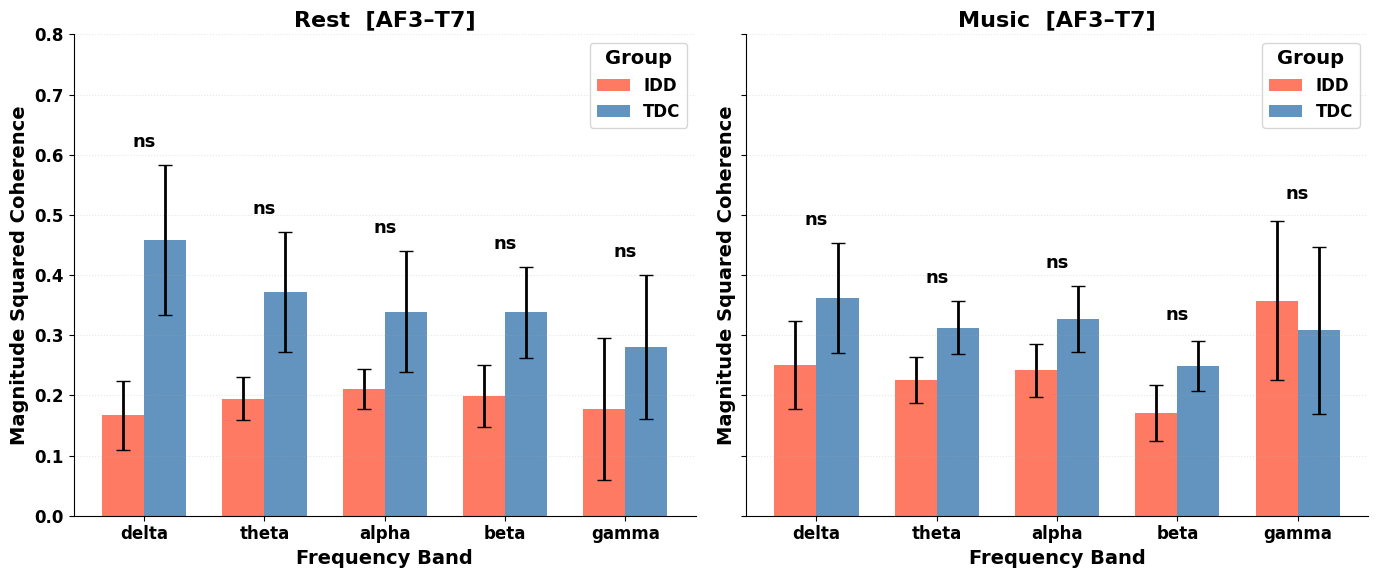

In [13]:
# Cell 6 (corrected) — Spectral Coherence via Welch (MSC)
# More discriminative than smoothed CWT coherence

from scipy.signal import coherence as scipy_coherence

print("Computing Welch spectral coherence AF3-T7 for all subjects...")

coh_welch = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for subj, group, cond, _ in MANIFEST:
    sig1 = data[(subj,cond)]['eeg'][ch1_idx].astype(np.float64)
    sig2 = data[(subj,cond)]['eeg'][ch2_idx].astype(np.float64)
    sig1 = np.clip(sig1, -5*sig1.std(), 5*sig1.std())
    sig2 = np.clip(sig2, -5*sig2.std(), 5*sig2.std())

    # Magnitude squared coherence via Welch
    f, Cxy = scipy_coherence(sig1, sig2, fs=SFREQ, nperseg=256)

    for bname, (flo, fhi) in BANDS.items():
        mask = (f >= flo) & (f < fhi)
        coh_welch[group][cond][bname].append(Cxy[mask].mean())

    print(f"  {subj} {cond}  range=[{Cxy.min():.3f}, {Cxy.max():.3f}]")

print("\nPlotting...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
x     = np.arange(len(BANDS))
width = 0.35

for ax, cond in zip(axes, ['Rest', 'Music']):
    for offset, (group, color) in enumerate(
            [('IDD','tomato'), ('TDC','steelblue')]):

        means = [np.mean(coh_welch[group][cond][b]) for b in bnames]
        sems  = [np.std(coh_welch[group][cond][b]) /
                 np.sqrt(len(coh_welch[group][cond][b])) for b in bnames]

        ax.bar(x + offset*width, means, width,
               label=group, color=color, alpha=0.85,
               yerr=sems, capsize=5, error_kw={'linewidth':2})

    # Significance stars
    y_tops = []
    for bi, bname in enumerate(bnames):
        idd_vals = coh_welch['IDD'][cond][bname]
        tdc_vals = coh_welch['TDC'][cond][bname]
        _, p = mannwhitneyu(idd_vals, tdc_vals, alternative='two-sided')
        y_top = max(np.mean(idd_vals), np.mean(tdc_vals)) + \
                max(np.std(idd_vals), np.std(tdc_vals)) / \
                np.sqrt(7) + 0.03
        if p < 0.001:  star = '***'
        elif p < 0.01: star = '**'
        elif p < 0.05: star = '*'
        else:          star = 'ns'
        ax.text(bi + width/2, y_top, star,
                ha='center', fontsize=13, fontweight='bold')

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(bnames)
    ax.set_title(f'{cond}  [AF3–T7]')
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('Magnitude Squared Coherence')
    ax.set_ylim(0, 0.8)
    ax.legend(title='Group')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
save_fig('fig_msc_coherence_group.png')
plt.show()

Computing full 91-pair coherence for all subjects (this takes ~5 min)...
  NDS001 Music done
  NDS001 Rest done
  NDS002 Music done
  NDS002 Rest done
  NDS003 Music done
  NDS003 Rest done
  NDS004 Music done
  NDS004 Rest done
  NDS005 Music done
  NDS005 Rest done
  NDS006 Music done
  NDS006 Rest done
  NDS007 Music done
  NDS007 Rest done
  CGS01 Music done
  CGS01 Rest done
  CGS02 Music done
  CGS02 Rest done
  CGS03 Music done
  CGS03 Rest done
  CGS04 Music done
  CGS04 Rest done
  CGS05 Music done
  CGS05 Rest done
  CGS06 Music done
  CGS06 Rest done
  CGS07 Music done
  CGS07 Rest done

Plotting group-mean matrices...
Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_full_connectivity_matrix.png


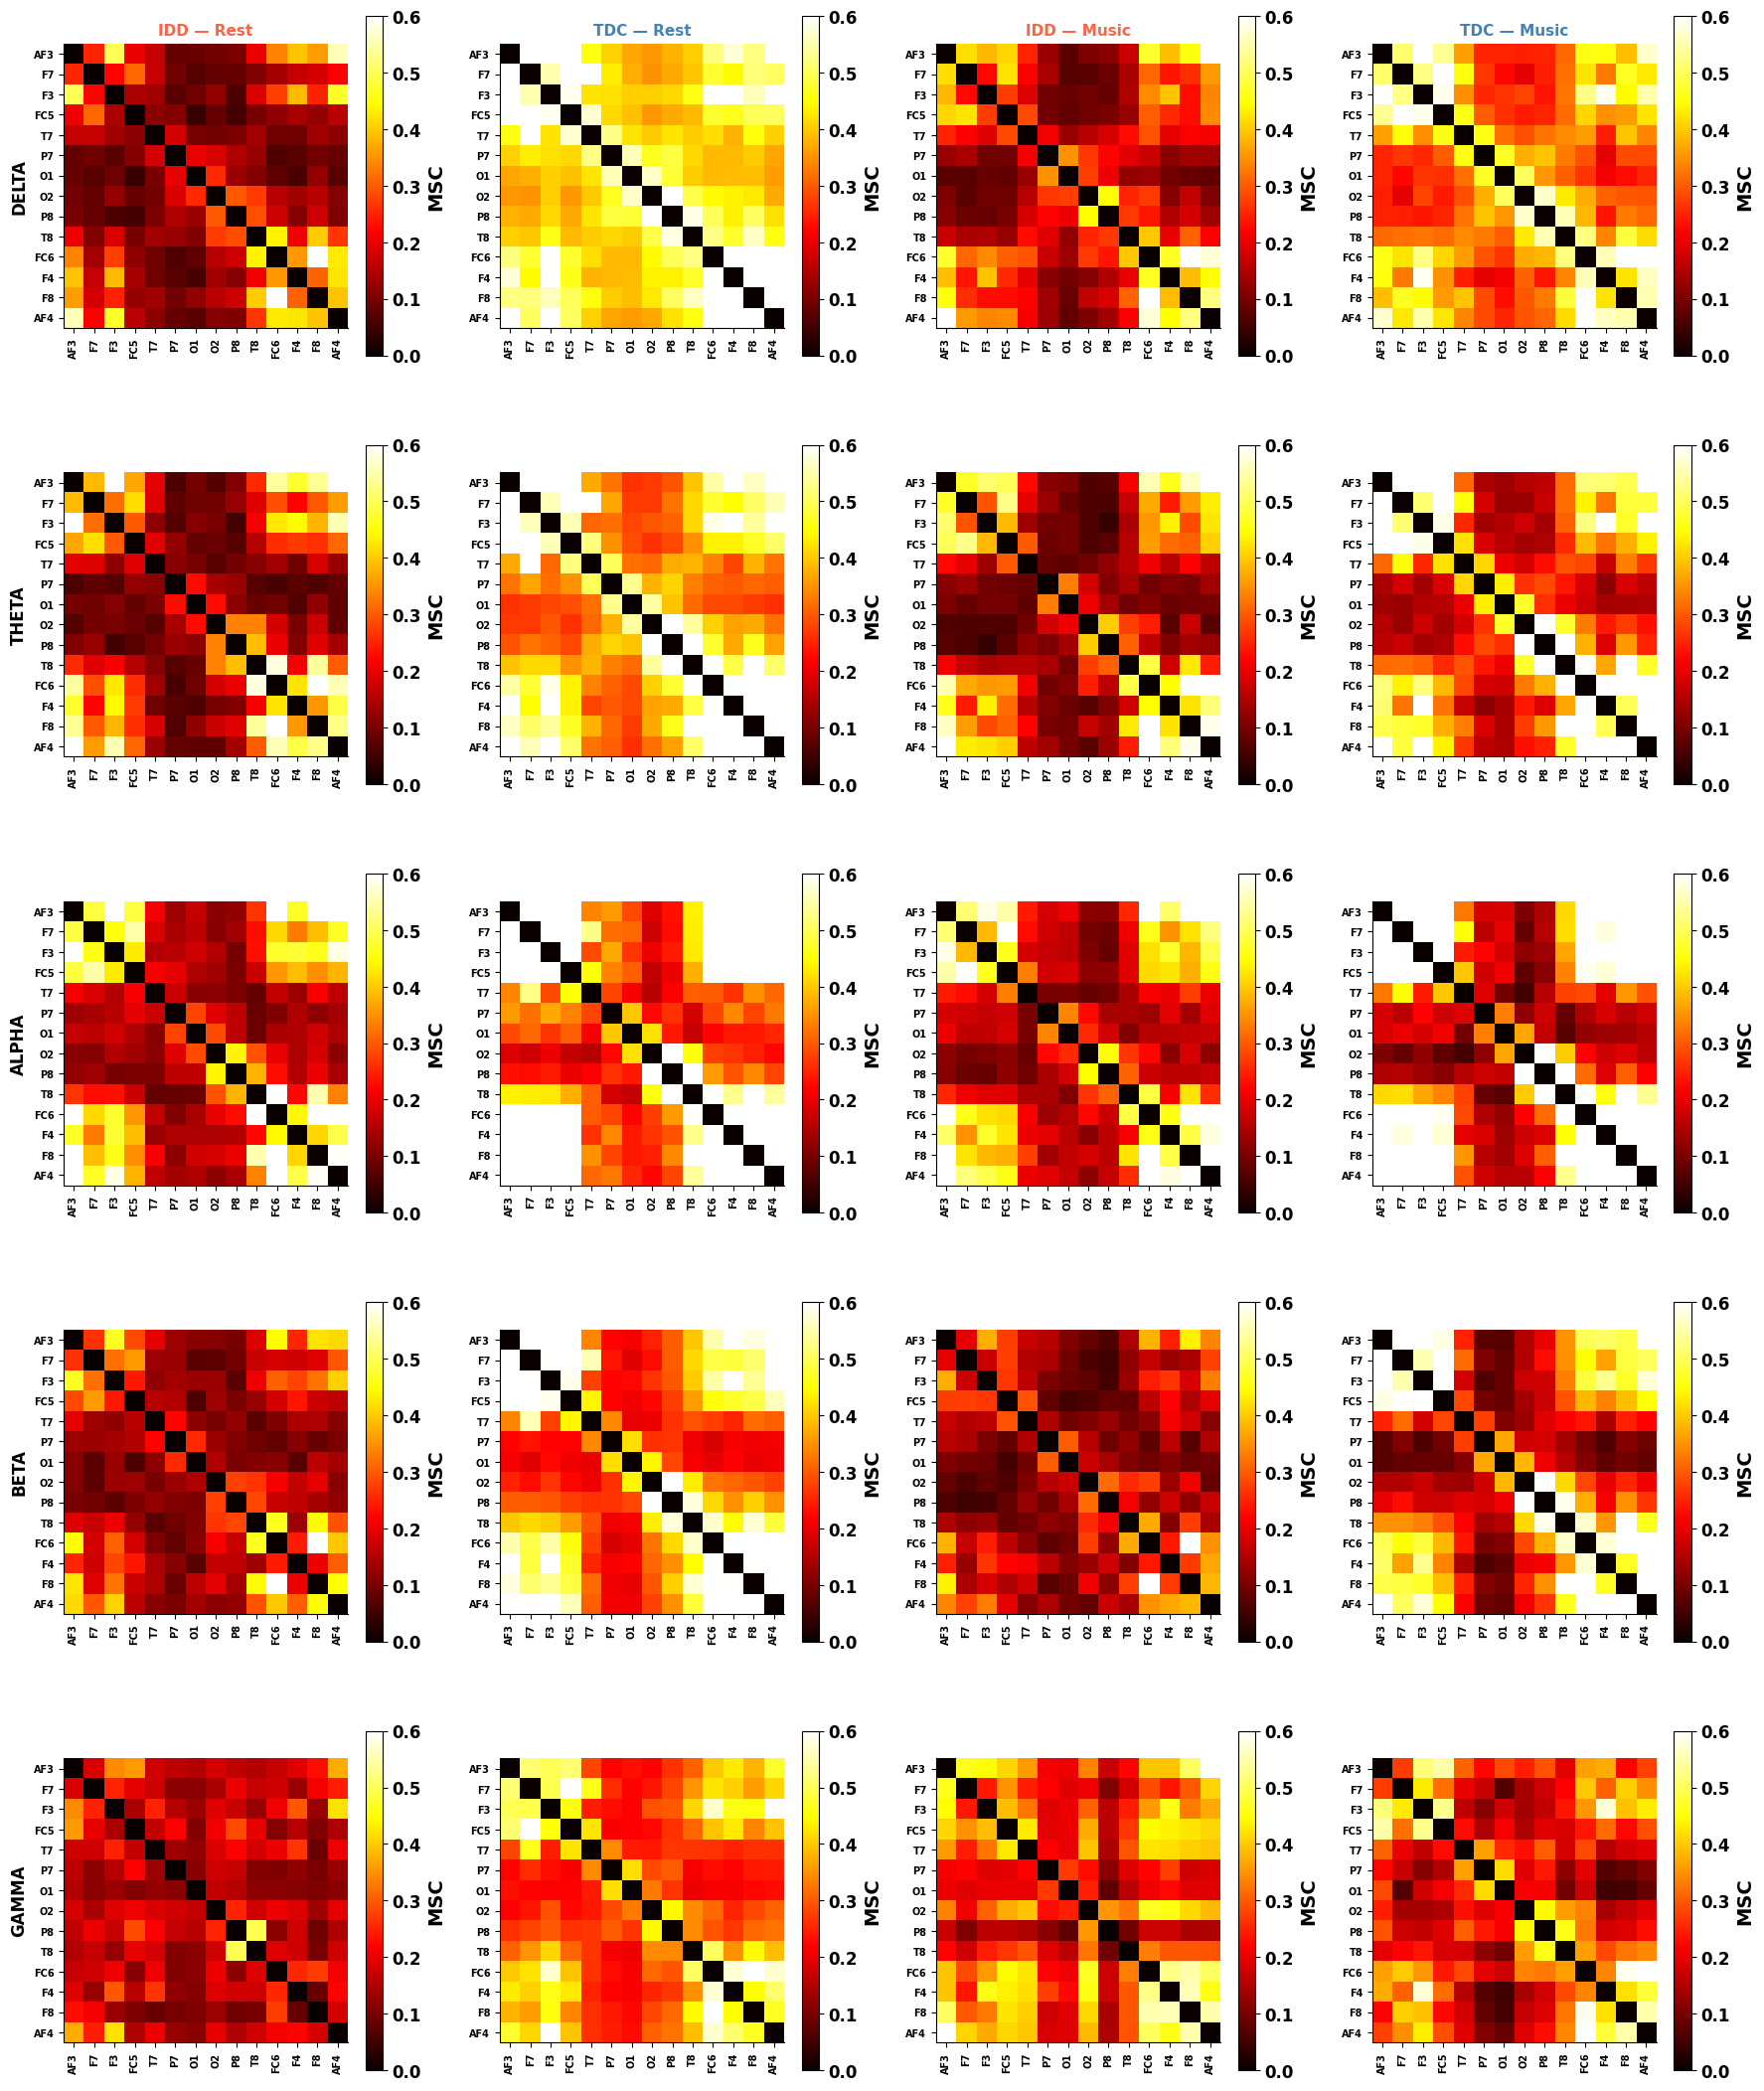

In [15]:
# Cell 7 — Full 91-pair MSC coherence matrix: IDD vs TDC group mean

from scipy.signal import coherence as scipy_coherence

print("Computing full 91-pair coherence for all subjects (this takes ~5 min)...")

# Store per-subject full connectivity matrix (14x14) per band per condition
# conn_subj[subj][cond][band] = (14,14) array
conn_subj = defaultdict(lambda: defaultdict(lambda: {}))

for subj, group, cond, _ in MANIFEST:
    eeg = data[(subj,cond)]['eeg'].astype(np.float64)

    for bname, (flo, fhi) in BANDS.items():
        mat = np.zeros((14, 14))
        for i in range(14):
            for j in range(i+1, 14):
                s1 = np.clip(eeg[i], -5*eeg[i].std(), 5*eeg[i].std())
                s2 = np.clip(eeg[j], -5*eeg[j].std(), 5*eeg[j].std())
                f, Cxy = scipy_coherence(s1, s2, fs=SFREQ, nperseg=256)
                mask = (f >= flo) & (f < fhi)
                val  = Cxy[mask].mean()
                mat[i,j] = val
                mat[j,i] = val
        conn_subj[subj][cond][bname] = mat

    print(f"  {subj} {cond} done")

print("\nPlotting group-mean matrices...")

# Compute group means
def group_mean_matrix(group, cond, bname):
    mats = []
    for subj, grp, c, _ in MANIFEST:
        if grp == group and c == cond:
            mats.append(conn_subj[subj][cond][bname])
    return np.mean(mats, axis=0)

# Plot: rows=bands, cols=[IDD Rest, TDC Rest, IDD Music, TDC Music]
plot_bands = ['delta','theta','alpha','beta','gamma']
fig, axes  = plt.subplots(len(plot_bands), 4, figsize=(18, 22))

col_labels = ['IDD — Rest','TDC — Rest','IDD — Music','TDC — Music']
col_specs  = [('IDD','Rest'),('TDC','Rest'),('IDD','Music'),('TDC','Music')]

for row, bname in enumerate(plot_bands):
    for col, (group, cond) in enumerate(col_specs):
        ax  = axes[row][col]
        mat = group_mean_matrix(group, cond, bname)
        np.fill_diagonal(mat, 0)

        color = 'tomato' if group == 'IDD' else 'steelblue'
        im = ax.imshow(mat, cmap='hot', vmin=0, vmax=0.6)
        ax.set_xticks(range(14))
        ax.set_xticklabels(CHANNELS, rotation=90, fontsize=7)
        ax.set_yticks(range(14))
        ax.set_yticklabels(CHANNELS, fontsize=7)

        if row == 0:
            ax.set_title(col_labels[col], color=color, fontsize=11)
        if col == 0:
            ax.set_ylabel(bname.upper(), fontsize=12, fontweight='bold')

        plt.colorbar(im, ax=ax, shrink=0.8, label='MSC')

plt.tight_layout()
save_fig('fig_full_connectivity_matrix.png')
plt.show()

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_connectivity_diff_matrix.png


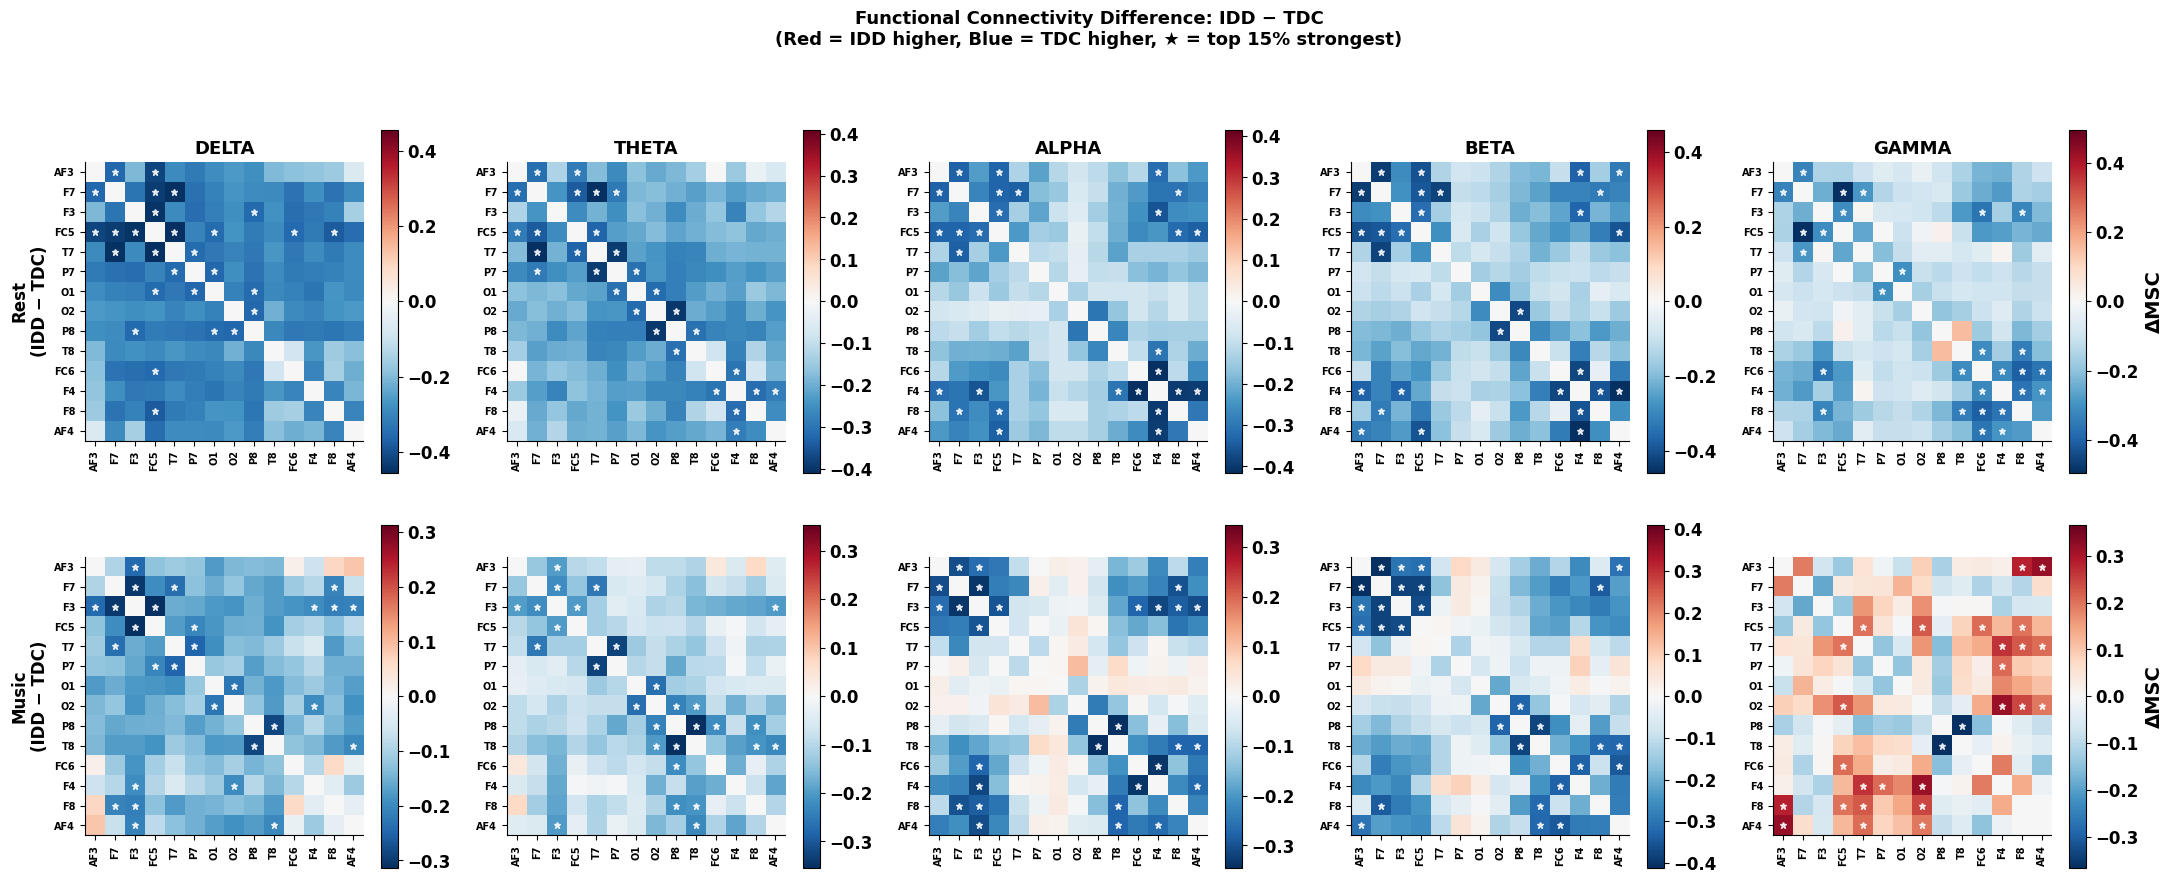

In [17]:
# Cell 8 — IDD minus TDC difference connectivity matrix (publishable biomarker figure)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for col, bname in enumerate(plot_bands):
    for row, cond in enumerate(['Rest', 'Music']):
        ax = axes[row][col]

        idd_mat = group_mean_matrix('IDD', cond, bname)
        tdc_mat = group_mean_matrix('TDC', cond, bname)
        diff    = idd_mat - tdc_mat
        np.fill_diagonal(diff, 0)

        vmax = np.abs(diff).max()
        im   = ax.imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)

        ax.set_xticks(range(14))
        ax.set_xticklabels(CHANNELS, rotation=90, fontsize=7)
        ax.set_yticks(range(14))
        ax.set_yticklabels(CHANNELS, fontsize=7)

        if row == 0:
            ax.set_title(bname.upper(), fontsize=13)
        if col == 0:
            ax.set_ylabel(f'{cond}\n(IDD − TDC)', fontsize=12,
                         fontweight='bold')

        plt.colorbar(im, ax=ax, shrink=0.85,
                     label='ΔMSC' if col == 4 else '')

        # Annotate strongest connections
        diff_abs = np.abs(diff.copy())
        np.fill_diagonal(diff_abs, 0)
        threshold = np.percentile(diff_abs[diff_abs > 0], 85)
        for i in range(14):
            for j in range(14):
                if diff_abs[i,j] >= threshold:
                    ax.plot(j, i, 'w*', markersize=5, alpha=0.8)

plt.suptitle('Functional Connectivity Difference: IDD − TDC\n'
             '(Red = IDD higher, Blue = TDC higher, ★ = top 15% strongest)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('fig_connectivity_diff_matrix.png')
plt.show()

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_network_graph.png


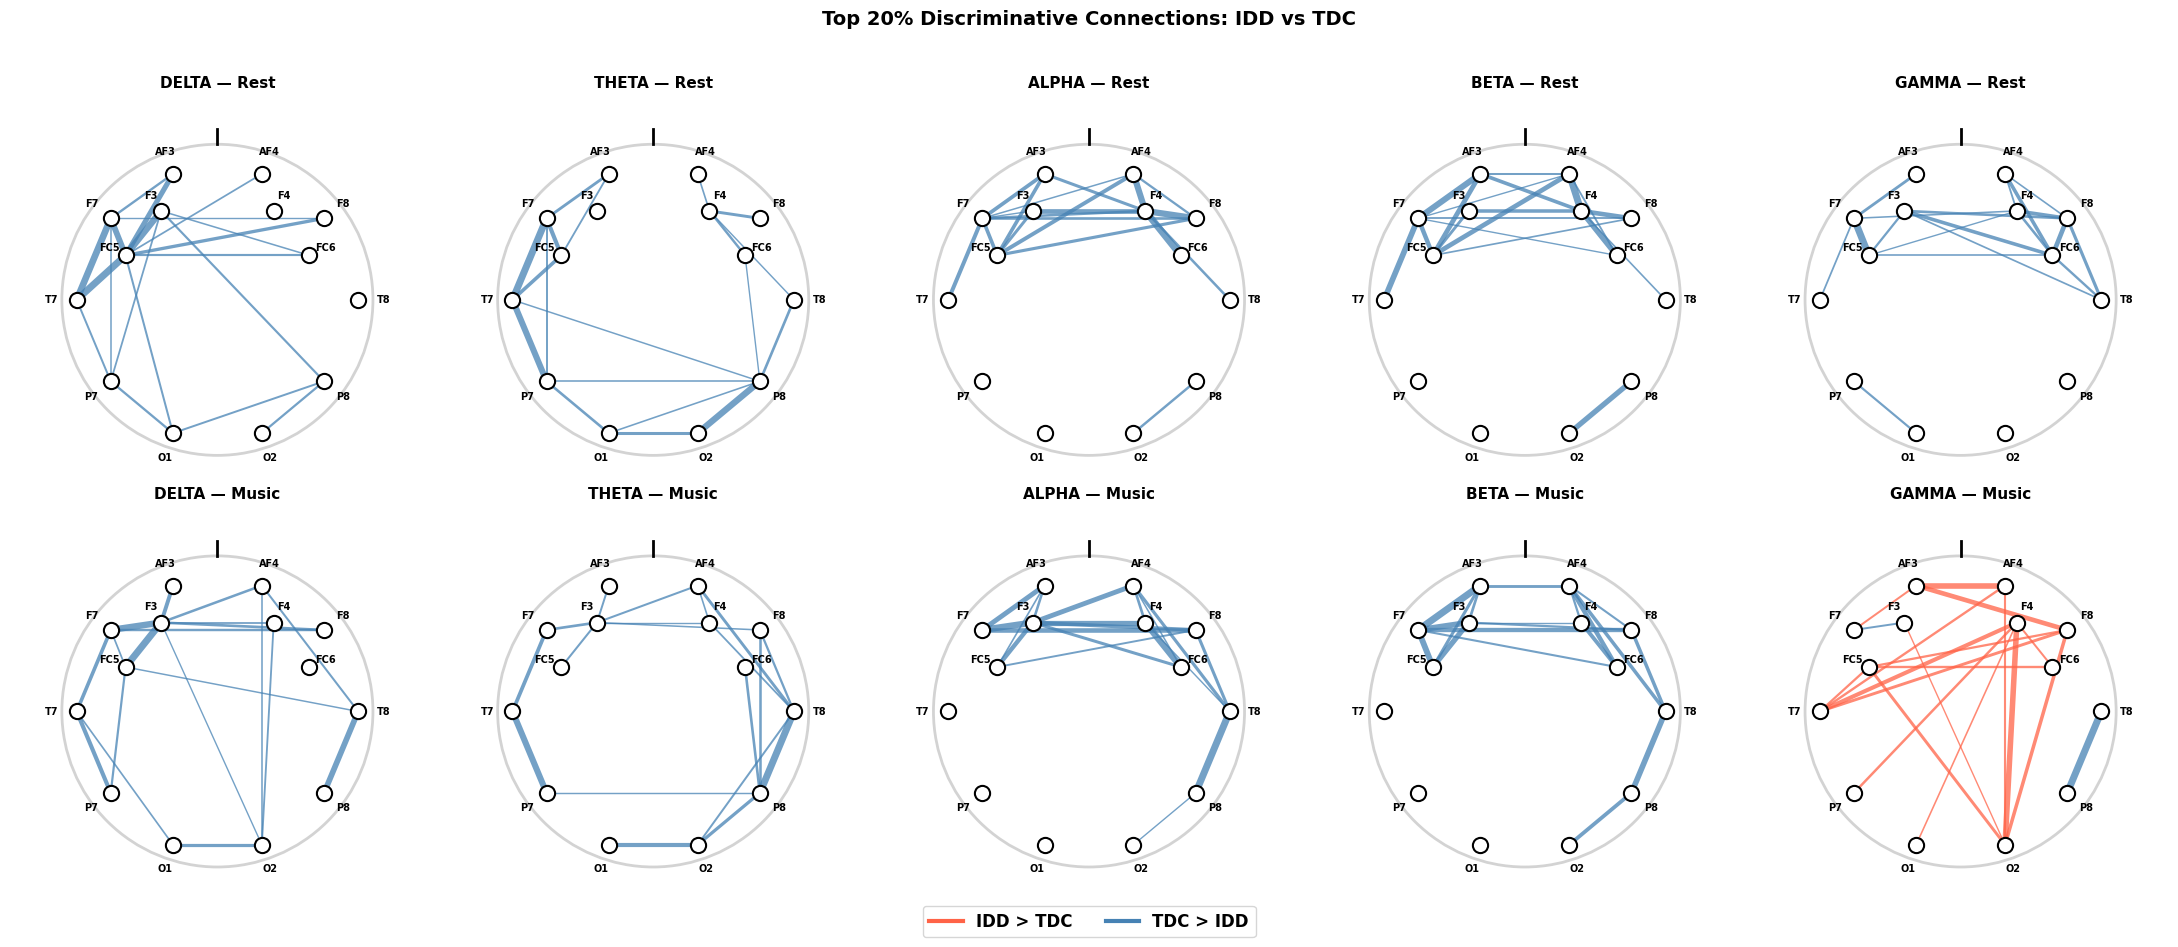

In [19]:
# Cell 9 — Network graph on scalp layout: top discriminative connections

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# EMOTIV electrode positions (normalized to unit circle, approximate 10-20)
CH_POS = {
    'AF3': (-0.30,  0.85), 'AF4': ( 0.30,  0.85),
    'F7' : (-0.72,  0.55), 'F8' : ( 0.72,  0.55),
    'F3' : (-0.38,  0.60), 'F4' : ( 0.38,  0.60),
    'FC5': (-0.62,  0.30), 'FC6': ( 0.62,  0.30),
    'T7' : (-0.95,  0.00), 'T8' : ( 0.95,  0.00),
    'P7' : (-0.72, -0.55), 'P8' : ( 0.72, -0.55),
    'O1' : (-0.30, -0.90), 'O2' : ( 0.30, -0.90),
}

def draw_network(ax, diff_mat, channels, title,
                 top_pct=20, pos=CH_POS):
    # Head circle
    circle = plt.Circle((0,0), 1.05, color='lightgray',
                         fill=False, linewidth=2)
    ax.add_patch(circle)
    # Nose
    ax.plot([0, 0], [1.05, 1.15], 'k-', linewidth=2)

    diff_abs = np.abs(diff_mat.copy())
    np.fill_diagonal(diff_abs, 0)
    threshold = np.percentile(diff_abs[diff_abs > 0], 100 - top_pct)

    # Draw edges
    for i in range(len(channels)):
        for j in range(i+1, len(channels)):
            val = diff_mat[i, j]
            if abs(val) >= threshold:
                x1,y1 = pos[channels[i]]
                x2,y2 = pos[channels[j]]
                color = 'tomato' if val > 0 else 'steelblue'
                lw    = 1 + 4 * (abs(val) - threshold) / (diff_abs.max() - threshold + 1e-8)
                ax.plot([x1,x2], [y1,y2], color=color,
                        linewidth=lw, alpha=0.75, zorder=1)

    # Draw nodes
    for ch in channels:
        x, y = pos[ch]
        ax.scatter(x, y, s=120, color='white',
                   edgecolors='black', linewidth=1.5, zorder=3)
        offset_x = x * 0.18
        offset_y = y * 0.18
        ax.text(x + offset_x, y + offset_y, ch,
                ha='center', va='center', fontsize=7,
                fontweight='bold', zorder=4)

    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.3, 1.4)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, pad=4)

# Plot: 2 rows (Rest/Music) x 5 bands
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

legend_elements = [
    Line2D([0],[0], color='tomato',    linewidth=3, label='IDD > TDC'),
    Line2D([0],[0], color='steelblue', linewidth=3, label='TDC > IDD'),
]

for col, bname in enumerate(plot_bands):
    for row, cond in enumerate(['Rest', 'Music']):
        ax = axes[row][col]

        idd_mat = group_mean_matrix('IDD', cond, bname)
        tdc_mat = group_mean_matrix('TDC', cond, bname)
        diff    = idd_mat - tdc_mat
        np.fill_diagonal(diff, 0)

        title = f'{bname.upper()}\n{cond}' if row == 0 else ''
        if row == 1 and col == 0:
            title = f'Music'
        draw_network(ax, diff, CHANNELS,
                     title=f'{bname.upper()} — {cond}')

fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=12, frameon=True,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Top 20% Discriminative Connections: IDD vs TDC',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fig_network_graph.png')
plt.show()

In [23]:
# Diagnostic — check for inf/nan in computed metrics
for group in ['IDD','TDC']:
    for cond in ['Rest','Music']:
        for bname in plot_bands:
            for metric in METRIC_NAMES:
                key  = f'{bname}_{metric}'
                vals = np.array(metrics_all[group][cond][key])
                if not np.all(np.isfinite(vals)):
                    bad = np.sum(~np.isfinite(vals))
                    print(f"  BAD: {group} {cond} {key}  "
                          f"{bad} non-finite values  range=[{np.nanmin(vals):.3g}, {np.nanmax(vals):.3g}]")
print("Diagnostic done")

Diagnostic done


Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_graph_metrics.png


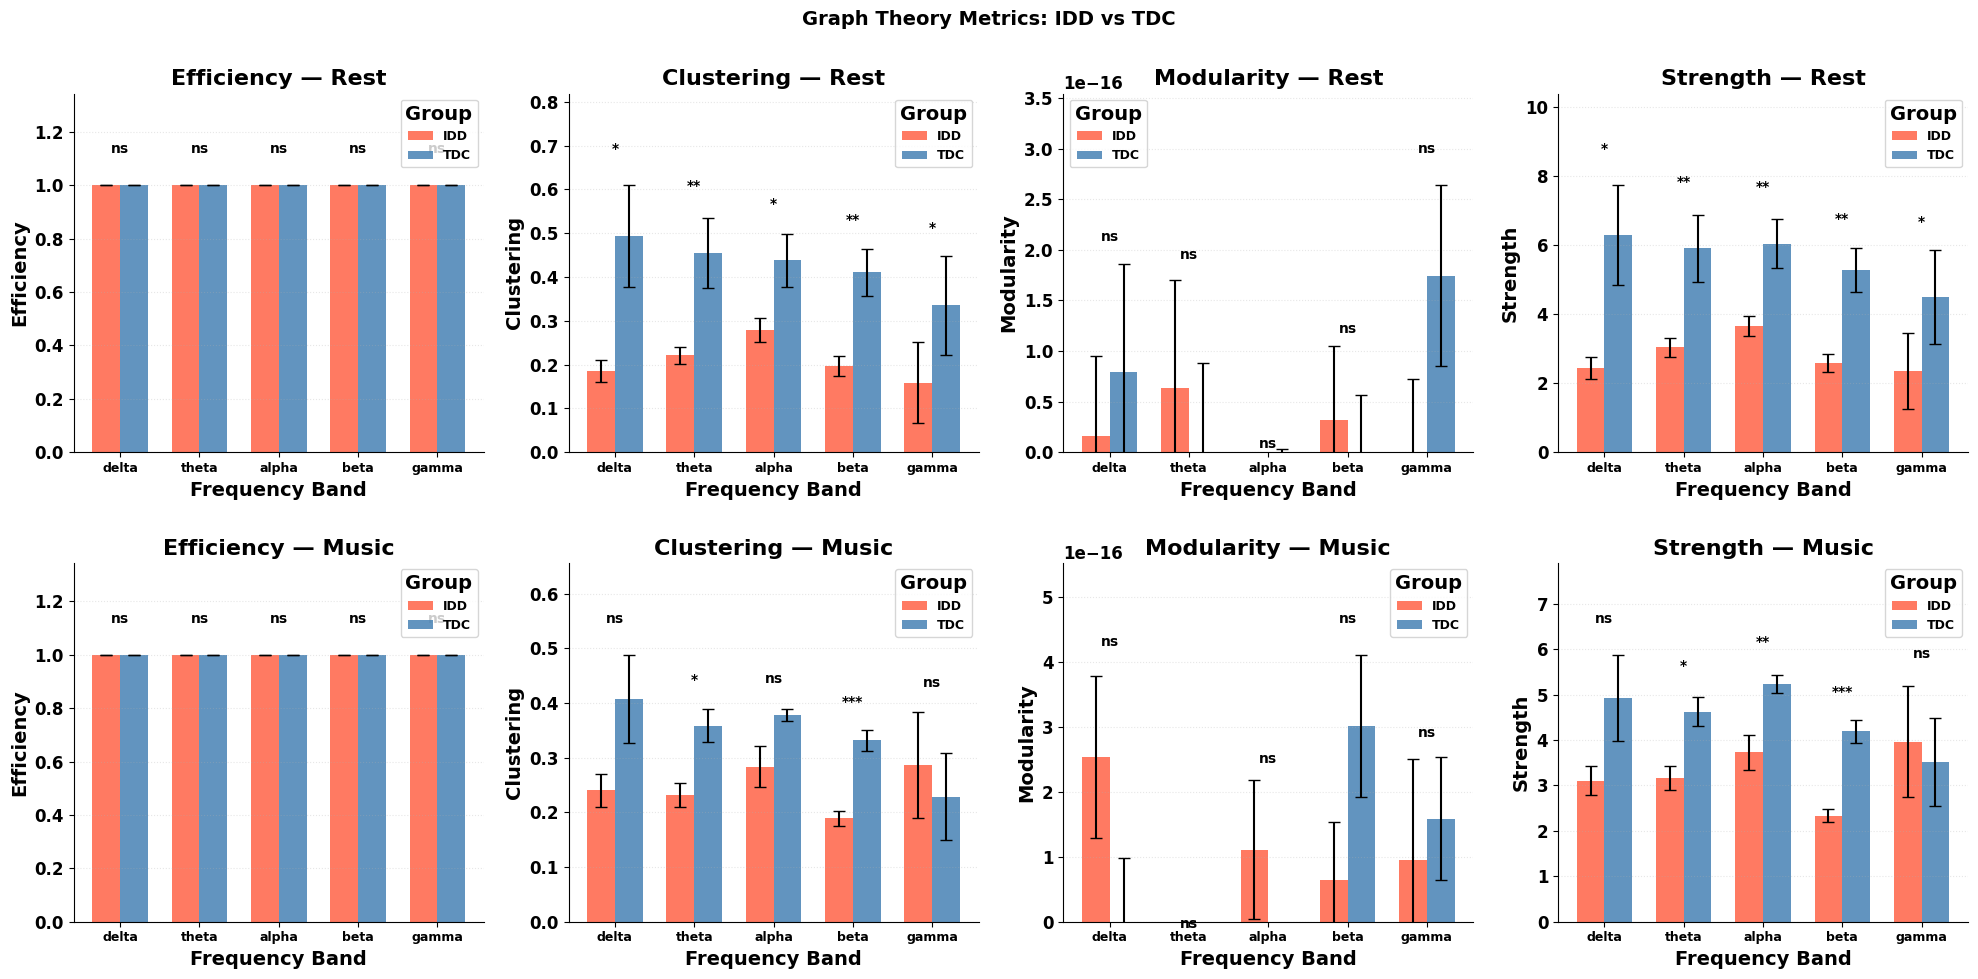

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=False)

for col, metric in enumerate(METRIC_NAMES):
    for row, cond in enumerate(['Rest','Music']):
        ax    = axes[row][col]
        x     = np.arange(len(plot_bands))
        width = 0.35

        for offset, (group, color) in enumerate(
                [('IDD','tomato'),('TDC','steelblue')]):
            means = []
            sems  = []
            for bname in plot_bands:
                key  = f'{bname}_{metric}'
                vals = np.array(metrics_all[group][cond][key])
                means.append(np.nanmean(vals))
                sems.append(np.nanstd(vals) / np.sqrt(len(vals)))

            ax.bar(x + offset*width, means, width,
                   label=group, color=color, alpha=0.85,
                   yerr=sems, capsize=4,
                   error_kw={'linewidth':1.5})

        # Significance + safe y positioning
        all_vals_for_ylim = []
        for bi, bname in enumerate(plot_bands):
            key      = f'{bname}_{metric}'
            idd_vals = np.array(metrics_all['IDD'][cond][key])
            tdc_vals = np.array(metrics_all['TDC'][cond][key])
            _, p     = mannwhitneyu(idd_vals, tdc_vals,
                                    alternative='two-sided')

            idd_top = np.nanmean(idd_vals) + np.nanstd(idd_vals)/np.sqrt(7)
            tdc_top = np.nanmean(tdc_vals) + np.nanstd(tdc_vals)/np.sqrt(7)
            y_top   = max(idd_top, tdc_top) * 1.12
            all_vals_for_ylim.append(y_top)

            if   p < 0.001: star = '***'
            elif p < 0.01:  star = '**'
            elif p < 0.05:  star = '*'
            else:           star = 'ns'

            ax.text(bi + width/2, y_top, star,
                    ha='center', fontsize=10, fontweight='bold')

        # Safe ylim
        y_ceiling = max(all_vals_for_ylim) * 1.20
        ax.set_ylim(0, y_ceiling)

        ax.set_xticks(x + width/2)
        ax.set_xticklabels(plot_bands, fontsize=9)
        ax.set_xlabel('Frequency Band')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'{metric.capitalize()} — {cond}')
        ax.legend(title='Group', fontsize=9)
        ax.grid(True, axis='y', alpha=0.3, linestyle=':')

plt.suptitle('Graph Theory Metrics: IDD vs TDC',
             fontsize=14, fontweight='bold')
plt.tight_layout()

# Save at 300 dpi — 20x10 inch figure is already very high res
path = os.path.join(FIG_DIR, 'fig_graph_metrics.png')
plt.savefig(path, dpi=300, bbox_inches='tight')
print(f"Saved: {path}")
plt.show()

Saved: D:\Data science Project\EEG Chrononet\EEGdata\figures\fig_graph_summary.png


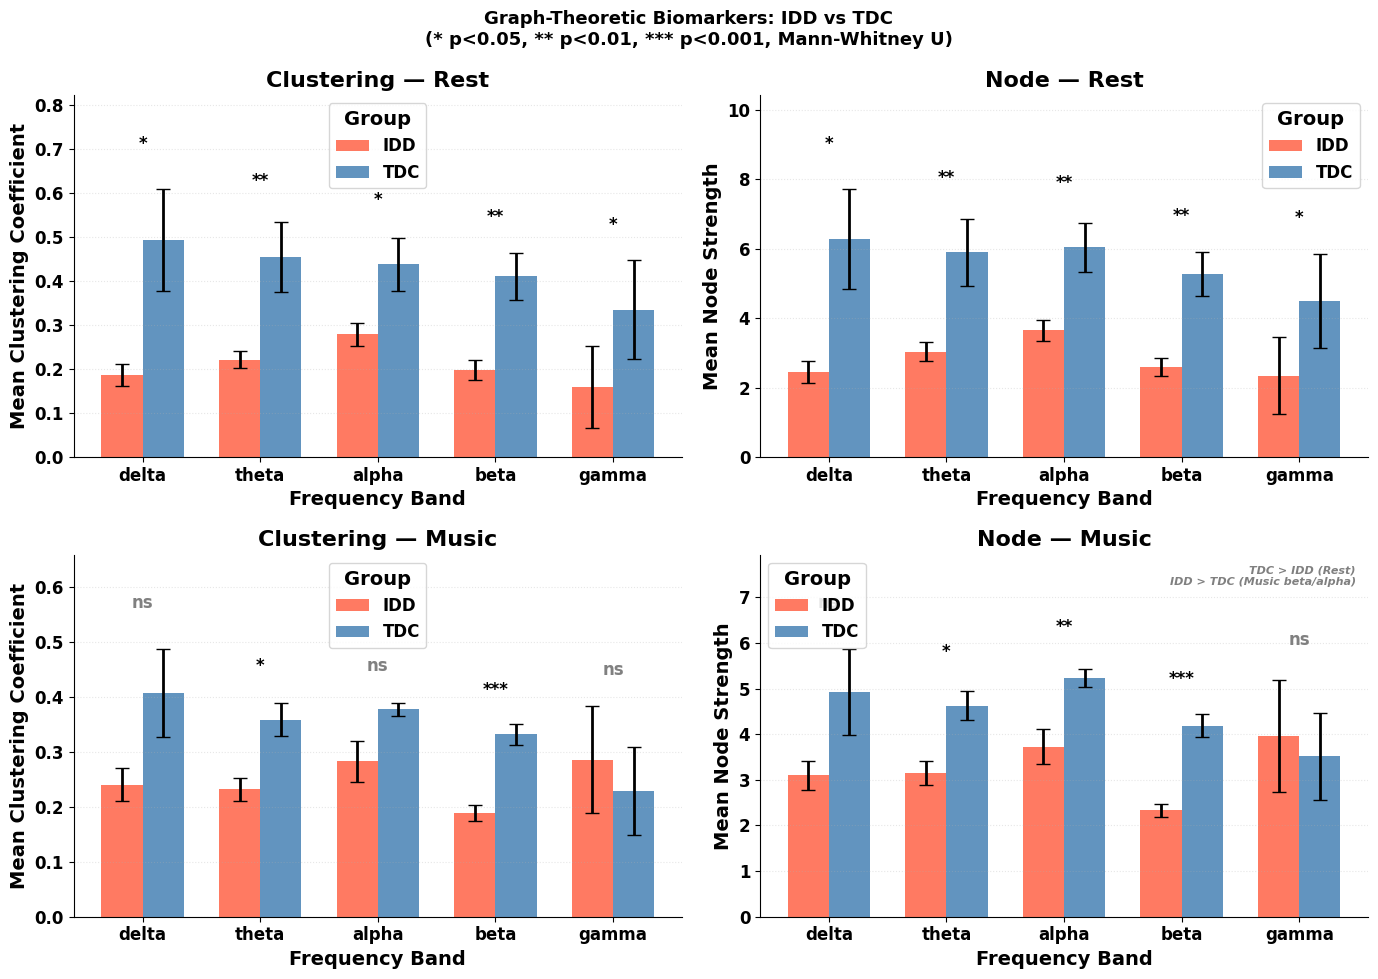

In [27]:
# Cell 11 — Clean summary: Clustering + Strength only (publishable)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_metrics  = ['clustering', 'strength']
metric_labels = ['Mean Clustering Coefficient', 'Mean Node Strength']

for col, (metric, ylabel) in enumerate(zip(plot_metrics, metric_labels)):
    for row, cond in enumerate(['Rest', 'Music']):
        ax    = axes[row][col]
        x     = np.arange(len(plot_bands))
        width = 0.35

        for offset, (group, color) in enumerate(
                [('IDD','tomato'),('TDC','steelblue')]):
            means, sems = [], []
            for bname in plot_bands:
                vals = np.array(metrics_all[group][cond][f'{bname}_{metric}'])
                means.append(np.nanmean(vals))
                sems.append(np.nanstd(vals) / np.sqrt(len(vals)))

            ax.bar(x + offset*width, means, width,
                   label=group, color=color, alpha=0.85,
                   yerr=sems, capsize=5,
                   error_kw={'linewidth':2})

        # Significance
        for bi, bname in enumerate(plot_bands):
            idd_vals = np.array(metrics_all['IDD'][cond][f'{bname}_{metric}'])
            tdc_vals = np.array(metrics_all['TDC'][cond][f'{bname}_{metric}'])
            _, p = mannwhitneyu(idd_vals, tdc_vals, alternative='two-sided')

            idd_top = np.nanmean(idd_vals) + np.nanstd(idd_vals)/np.sqrt(7)
            tdc_top = np.nanmean(tdc_vals) + np.nanstd(tdc_vals)/np.sqrt(7)
            y_top   = max(idd_top, tdc_top) * 1.15

            if   p < 0.001: star = '***'
            elif p < 0.01:  star = '**'
            elif p < 0.05:  star = '*'
            else:           star = 'ns'

            ax.text(bi + width/2, y_top, star,
                    ha='center', fontsize=12, fontweight='bold',
                    color='black' if star != 'ns' else 'gray')

        # Ceiling
        all_top = []
        for bname in plot_bands:
            for group in ['IDD','TDC']:
                vals = np.array(metrics_all[group][cond][f'{bname}_{metric}'])
                all_top.append(np.nanmean(vals) + np.nanstd(vals)/np.sqrt(7))
        ax.set_ylim(0, max(all_top) * 1.35)

        ax.set_xticks(x + width/2)
        ax.set_xticklabels(plot_bands)
        ax.set_xlabel('Frequency Band')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel.split()[1]} — {cond}')
        ax.legend(title='Group')
        ax.grid(True, axis='y', alpha=0.3, linestyle=':')

        # Annotate direction of significant differences
        ax.text(0.98, 0.97,
                'TDC > IDD (Rest)\nIDD > TDC (Music beta/alpha)' if cond=='Music' and metric=='strength'
                else '',
                transform=ax.transAxes, fontsize=8,
                ha='right', va='top', color='gray', style='italic')

plt.suptitle('Graph-Theoretic Biomarkers: IDD vs TDC\n'
             '(* p<0.05, ** p<0.01, *** p<0.001, Mann-Whitney U)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
path = os.path.join(FIG_DIR, 'fig_graph_summary.png')
plt.savefig(path, dpi=300, bbox_inches='tight')
print(f"Saved: {path}")
plt.show()

In [ ]:
# Cell 12 — Small-worldness (sigma = C_real/C_rand / L_real/L_rand)

import networkx as nx
from scipy.stats import mannwhitneyu

def small_worldness(mat, n_rand=100):
    """
    Compute sigma = (C/C_rand) / (L/L_rand)
    sigma > 1 = small-world topology
    """
    np.fill_diagonal(mat, 0)
    mat = np.abs(mat)
    G   = nx.from_numpy_array(mat)

    # Real network metrics
    C_real = nx.average_clustering(G, weight='weight')
    try:
        L_real = nx.average_shortest_path_length(G, weight='weight')
    except Exception:
        L_real = np.nan

    if not np.isfinite(L_real) or L_real == 0:
        return np.nan

    # Null: degree-preserving random networks
    C_rand_list, L_rand_list = [], []
    for _ in range(n_rand):
        G_rand = nx.random_reference(G, niter=5, connectivity=False)
        C_rand_list.append(nx.average_clustering(G_rand, weight='weight'))
        try:
            L_rand_list.append(
                nx.average_shortest_path_length(G_rand, weight='weight'))
        except Exception:
            L_rand_list.append(np.nan)

    C_rand = np.nanmean(C_rand_list)
    L_rand = np.nanmean(L_rand_list)

    if C_rand == 0 or L_rand == 0:
        return np.nan

    sigma = (C_real / C_rand) / (L_real / L_rand)
    return sigma

print("Computing small-worldness (n_rand=100 per subject per band)...")
print("This will take ~10-15 minutes. Progress below:\n")

sw_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
# sw_results[group][cond][band] = list of sigma values (one per subject)

total = len(MANIFEST) * len(plot_bands)
done  = 0

for subj, group, cond, _ in MANIFEST:
    for bname in plot_bands:
        mat   = conn_subj[subj][cond][bname].copy()
        sigma = small_worldness(mat, n_rand=100)
        sw_results[group][cond][bname].append(sigma)
        done += 1
        print(f"  [{done:3d}/{total}] {subj} {cond} {bname:6s}  "
              f"sigma={sigma:.3f}" if np.isfinite(sigma)
              else f"  [{done:3d}/{total}] {subj} {cond} {bname:6s}  sigma=NaN",
              flush=True)

print("\nDone. Plotting...")

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
x     = np.arange(len(plot_bands))
width = 0.35

for ax, cond in zip(axes, ['Rest','Music']):
    for offset, (group, color) in enumerate(
            [('IDD','tomato'),('TDC','steelblue')]):
        means, sems = [], []
        for bname in plot_bands:
            vals = np.array(sw_results[group][cond][bname])
            vals = vals[np.isfinite(vals)]
            means.append(np.mean(vals) if len(vals) else np.nan)
            sems.append(np.std(vals)/np.sqrt(len(vals)) if len(vals) > 1 else 0)

        ax.bar(x + offset*width, means, width,
               label=group, color=color, alpha=0.85,
               yerr=sems, capsize=5, error_kw={'linewidth':2})

    # sigma=1 reference line
    ax.axhline(1.0, color='black', linewidth=1.5,
               linestyle='--', label='σ=1 (random)')

    # Significance
    for bi, bname in enumerate(plot_bands):
        idd_v = np.array(sw_results['IDD'][cond][bname])
        tdc_v = np.array(sw_results['TDC'][cond][bname])
        idd_v = idd_v[np.isfinite(idd_v)]
        tdc_v = tdc_v[np.isfinite(tdc_v)]

        if len(idd_v) < 3 or len(tdc_v) < 3:
            star = 'ns'
        else:
            _, p = mannwhitneyu(idd_v, tdc_v, alternative='two-sided')
            if   p < 0.001: star = '***'
            elif p < 0.01:  star = '**'
            elif p < 0.05:  star = '*'
            else:           star = 'ns'

        y_top = max(np.nanmean(idd_v), np.nanmean(tdc_v)) * 1.15
        ax.text(bi + width/2, y_top, star,
                ha='center', fontsize=12, fontweight='bold',
                color='black' if star != 'ns' else 'gray')

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(plot_bands)
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('Small-World Index (σ)')
    ax.set_title(f'Small-Worldness — {cond}')
    ax.legend(title='Group')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')

plt.suptitle('Small-World Index: IDD vs TDC\n'
             '(σ > 1 = small-world topology, dashed line = random network)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
path = os.path.join(FIG_DIR, 'fig_small_worldness.png')
plt.savefig(path, dpi=300, bbox_inches='tight')
print(f"Saved: {path}")
plt.show()

Computing small-worldness (n_rand=100 per subject per band)...
This will take ~10-15 minutes. Progress below:

  [  1/140] NDS001 Music delta   sigma=1.000
  [  2/140] NDS001 Music theta   sigma=1.000
  [  3/140] NDS001 Music alpha   sigma=1.000
  [  4/140] NDS001 Music beta    sigma=1.000
  [  5/140] NDS001 Music gamma   sigma=1.000
  [  6/140] NDS001 Rest delta   sigma=1.000
  [  7/140] NDS001 Rest theta   sigma=1.000
  [  8/140] NDS001 Rest alpha   sigma=1.000
  [  9/140] NDS001 Rest beta    sigma=1.000
  [ 10/140] NDS001 Rest gamma   sigma=1.000
  [ 11/140] NDS002 Music delta   sigma=1.000
  [ 12/140] NDS002 Music theta   sigma=1.000
  [ 13/140] NDS002 Music alpha   sigma=1.000
  [ 14/140] NDS002 Music beta    sigma=1.000
  [ 15/140] NDS002 Music gamma   sigma=1.000


In [ ]:
# Cell 12 (corrected) — Small-worldness on thresholded networks

def threshold_matrix(mat, density=0.25):
    """
    Keep only top `density` fraction of connections.
    density=0.25 means top 25% of edges retained.
    """
    mat = np.abs(mat.copy())
    np.fill_diagonal(mat, 0)
    thresh = np.percentile(mat[mat > 0], (1 - density) * 100)
    mat_t  = mat.copy()
    mat_t[mat_t < thresh] = 0
    return mat_t

def small_worldness_thresh(mat, density=0.25, n_rand=50):
    mat_t = threshold_matrix(mat, density)
    G     = nx.from_numpy_array(mat_t)

    # Remove isolates
    G.remove_nodes_from(list(nx.isolates(G)))
    if G.number_of_nodes() < 4:
        return np.nan

    C_real = nx.average_clustering(G, weight='weight')
    try:
        L_real = nx.average_shortest_path_length(G, weight='weight')
    except Exception:
        return np.nan

    if not np.isfinite(L_real) or L_real == 0:
        return np.nan

    C_rands, L_rands = [], []
    for _ in range(n_rand):
        try:
            G_r = nx.random_reference(G, niter=3, connectivity=False)
            G_r.remove_nodes_from(list(nx.isolates(G_r)))
            if G_r.number_of_nodes() < 4:
                continue
            C_rands.append(nx.average_clustering(G_r, weight='weight'))
            L_rands.append(nx.average_shortest_path_length(G_r, weight='weight'))
        except Exception:
            continue

    if len(C_rands) < 5:
        return np.nan

    C_rand = np.nanmean(C_rands)
    L_rand = np.nanmean(L_rands)

    if C_rand == 0 or L_rand == 0:
        return np.nan

    return (C_real / C_rand) / (L_real / L_rand)

# Run at density=0.25 (top 25% connections retained)
DENSITY = 0.25
print(f"Computing small-worldness (density={DENSITY}, n_rand=50)...")
print("~5-8 minutes. Progress:\n")

sw_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

total = len(MANIFEST) * len(plot_bands)
done  = 0

for subj, group, cond, _ in MANIFEST:
    for bname in plot_bands:
        mat   = conn_subj[subj][cond][bname].copy()
        sigma = small_worldness_thresh(mat, density=DENSITY, n_rand=50)
        sw_results[group][cond][bname].append(sigma)
        done += 1
        val_str = f"{sigma:.3f}" if np.isfinite(sigma) else "NaN"
        print(f"  [{done:3d}/{total}] {subj} {cond} {bname:6s}  sigma={val_str}",
              flush=True)

print("\nDone. Plotting...")

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
x     = np.arange(len(plot_bands))
width = 0.35

for ax, cond in zip(axes, ['Rest','Music']):
    for offset, (group, color) in enumerate(
            [('IDD','tomato'),('TDC','steelblue')]):
        means, sems = [], []
        for bname in plot_bands:
            vals = np.array(sw_results[group][cond][bname])
            vals = vals[np.isfinite(vals)]
            means.append(np.mean(vals) if len(vals) else np.nan)
            sems.append(np.std(vals)/np.sqrt(len(vals)) if len(vals)>1 else 0)

        ax.bar(x + offset*width, means, width,
               label=group, color=color, alpha=0.85,
               yerr=sems, capsize=5, error_kw={'linewidth':2})

    ax.axhline(1.0, color='black', linewidth=1.5,
               linestyle='--', label='σ=1 (random)')

    for bi, bname in enumerate(plot_bands):
        idd_v = np.array(sw_results['IDD'][cond][bname])
        tdc_v = np.array(sw_results['TDC'][cond][bname])
        idd_v = idd_v[np.isfinite(idd_v)]
        tdc_v = tdc_v[np.isfinite(tdc_v)]

        if len(idd_v) < 3 or len(tdc_v) < 3:
            star = 'ns'
        else:
            _, p = mannwhitneyu(idd_v, tdc_v, alternative='two-sided')
            if   p < 0.001: star = '***'
            elif p < 0.01:  star = '**'
            elif p < 0.05:  star = '*'
            else:           star = 'ns'

        y_top = max(np.nanmean(idd_v), np.nanmean(tdc_v)) * 1.15
        ax.text(bi + width/2, y_top, star,
                ha='center', fontsize=12, fontweight='bold',
                color='black' if star != 'ns' else 'gray')

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(plot_bands)
    ax.set_xlabel('Frequency Band')
    ax.set_ylabel('Small-World Index (σ)')
    ax.set_title(f'Small-Worldness — {cond}  (density={DENSITY})')
    ax.legend(title='Group')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')

plt.suptitle('Small-World Index: IDD vs TDC\n'
             f'(Top {int(DENSITY*100)}% connections, σ>1 = small-world)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
path = os.path.join(FIG_DIR, 'fig_small_worldness.png')
plt.savefig(path, dpi=300, bbox_inches='tight')
print(f"Saved: {path}")
plt.show()